In [4]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [5]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/Norway Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((209, 20789), (52, 20789), (209,), (52,))


Calculating SHAP values...
SHAP values shape: (52, 20789, 5)
Total features: 20789

=== Overall Top 10 Features ===
        Feature  MeanAbsSHAP_MaxAcrossSubtypes
16574  HIST1H1A                       0.003310
18826      DTX2                       0.002974
12933     CBWD3                       0.002748
8388        FGG                       0.002676
7783     NHEDC2                       0.002614
15912   TMPRSS5                       0.002483
3906       EXD1                       0.002222
10150     FABP9                       0.002173
17549    GPRIN2                       0.002147
18464      TLR1                       0.002077


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40588\1373605258.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


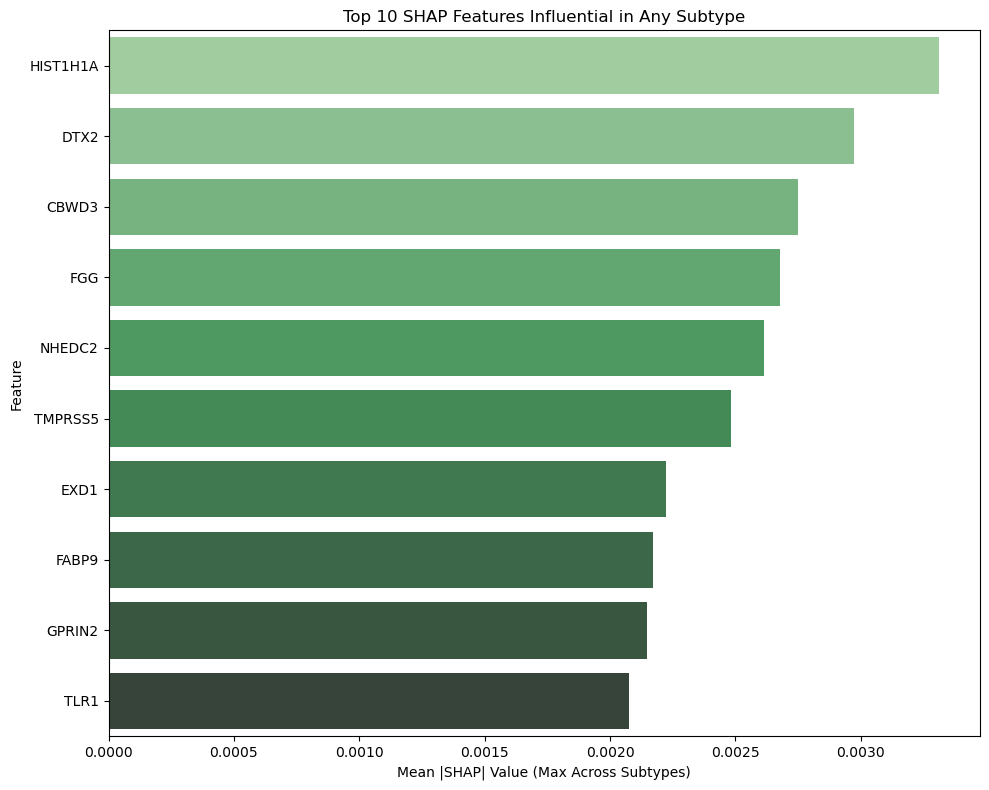

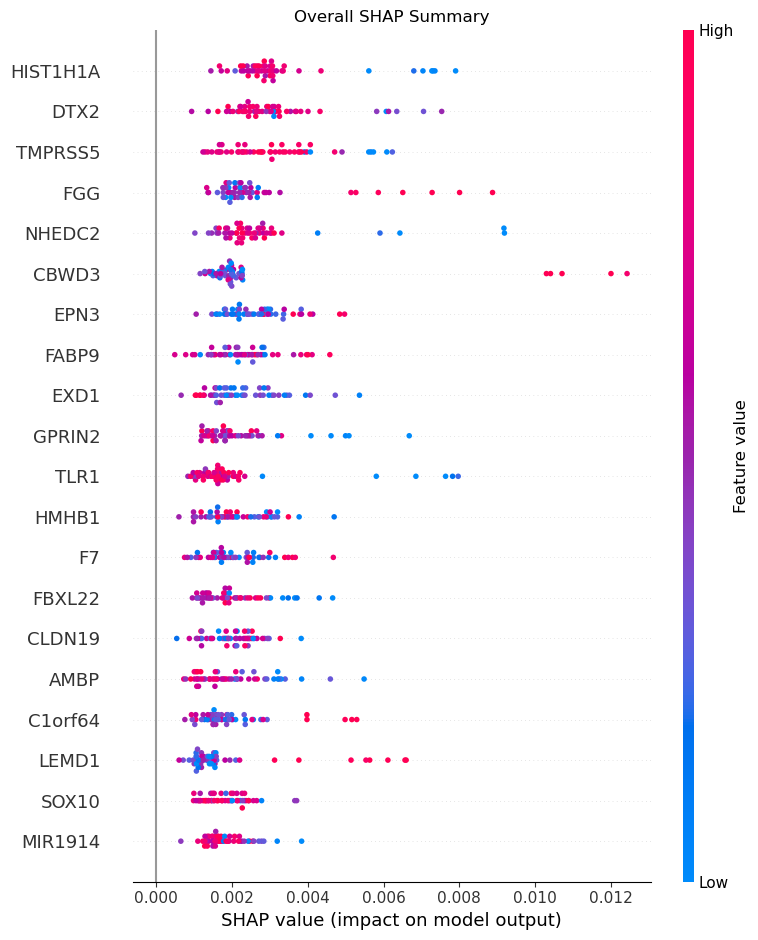


Subtype 1: Basal
        Feature  MeanAbsSHAP
16574  HIST1H1A     0.003310
12933     CBWD3     0.002748
8388        FGG     0.002676
7783     NHEDC2     0.002614
15912   TMPRSS5     0.002483
10150     FABP9     0.002173
17549    GPRIN2     0.002147
18464      TLR1     0.002077
11426      EPN3     0.002071
6415         F7     0.001973


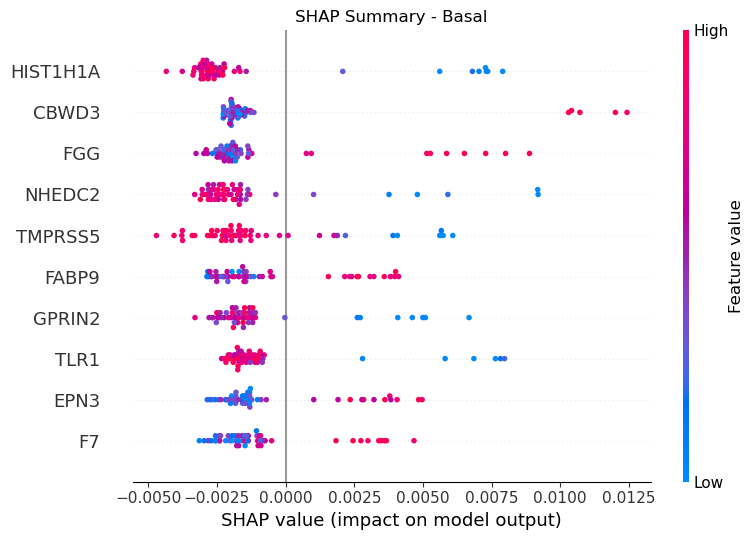

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40588\1373605258.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


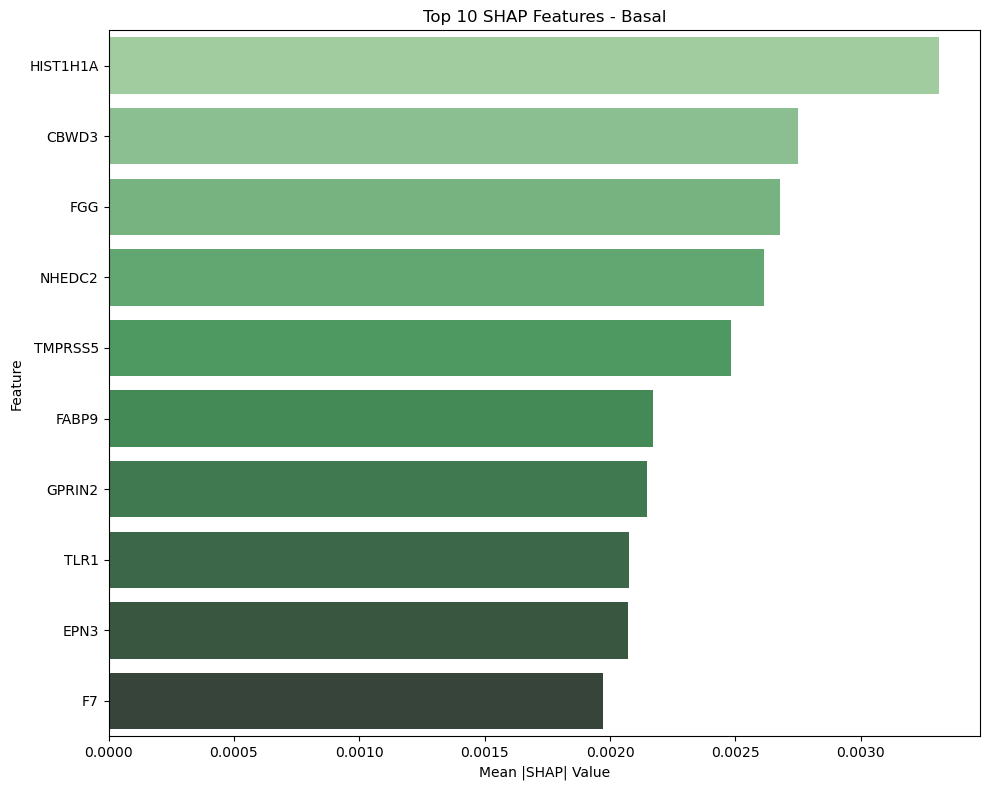


Subtype 2: Her2
       Feature  MeanAbsSHAP
18826     DTX2     0.002974
19638     AMBP     0.001977
12731   CPSF4L     0.001809
10761    NR1D1     0.001749
2303     TDRD1     0.001598
18777    HMHB1     0.001592
18872      HK3     0.001576
7267   CLRN1OS     0.001563
15542  COL16A1     0.001491
2451    TMEM26     0.001427


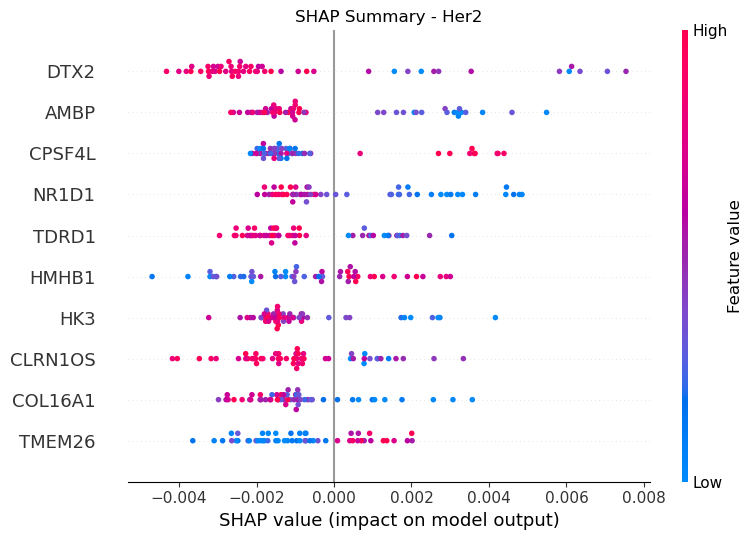

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40588\1373605258.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


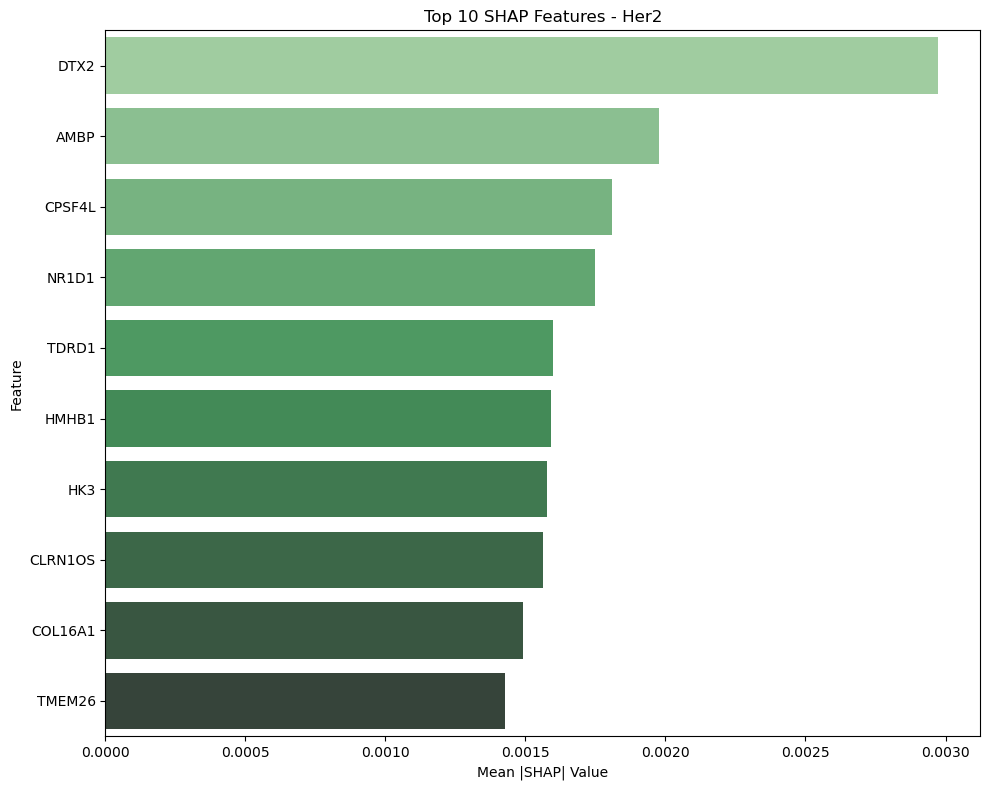


Subtype 3: LumA
        Feature  MeanAbsSHAP
18826      DTX2     0.001974
11426      EPN3     0.001611
7783     NHEDC2     0.001592
2237    C1orf59     0.001294
16574  HIST1H1A     0.001258
20405      CSTA     0.001244
8388        FGG     0.001241
18464      TLR1     0.001201
18638       SYP     0.001200
2451     TMEM26     0.001153


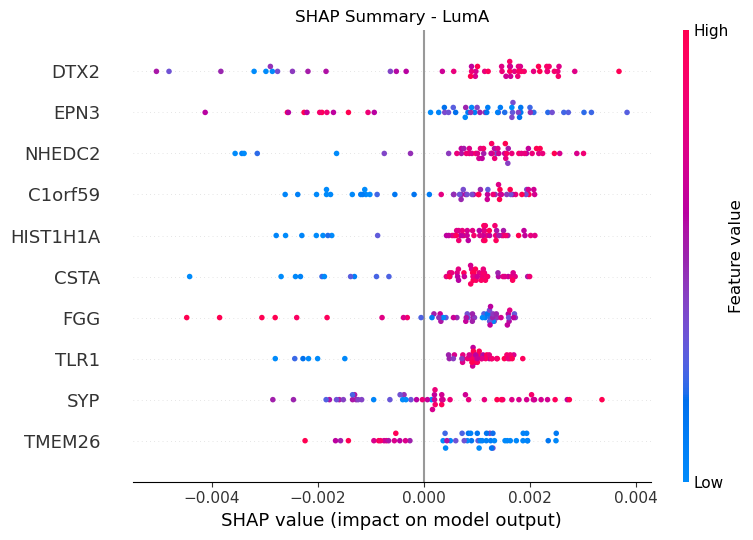

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40588\1373605258.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


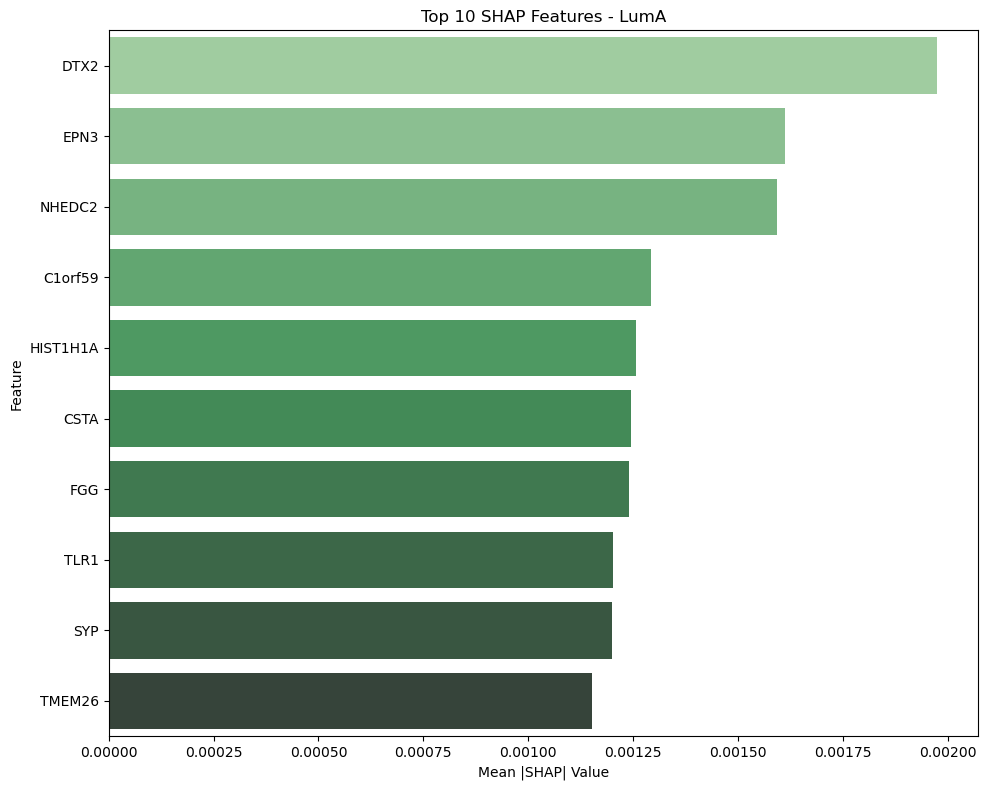


Subtype 4: LumB
       Feature  MeanAbsSHAP
15912  TMPRSS5     0.002167
18826     DTX2     0.001817
11426     EPN3     0.001795
18777    HMHB1     0.001667
7783    NHEDC2     0.001575
8388       FGG     0.001552
7882    FBXL22     0.001538
20218  C1orf64     0.001517
6415        F7     0.001473
18638      SYP     0.001469


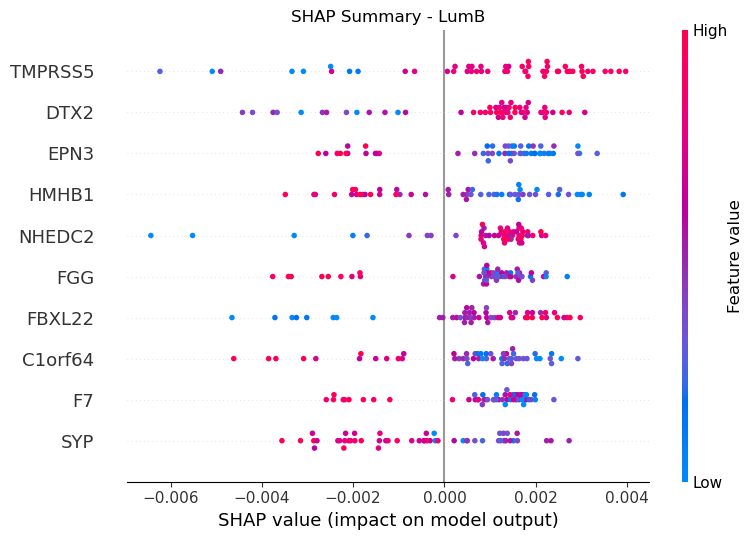

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40588\1373605258.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


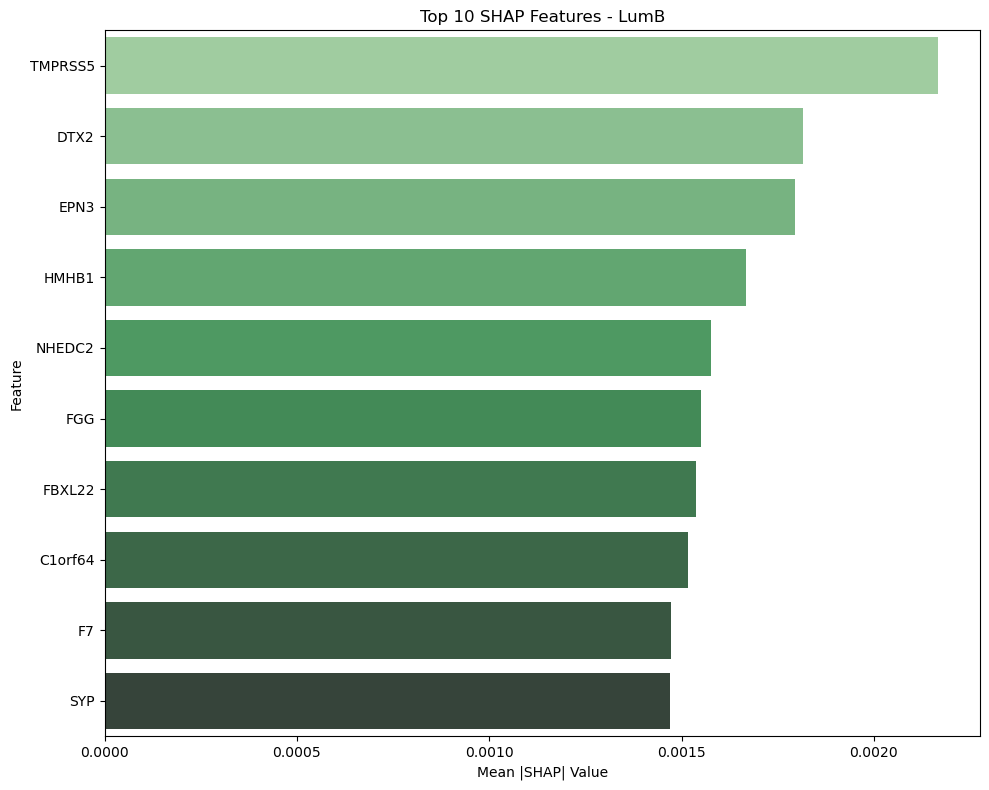


Subtype 5: Normal
       Feature  MeanAbsSHAP
3906      EXD1     0.002222
18382   CLDN19     0.001945
3905       CHP     0.001791
15912  TMPRSS5     0.001776
11426     EPN3     0.001712
20449    SOX10     0.001664
16313    JSRP1     0.001609
7882    FBXL22     0.001563
8957      GFAP     0.001518
20112  SLCO1A2     0.001500


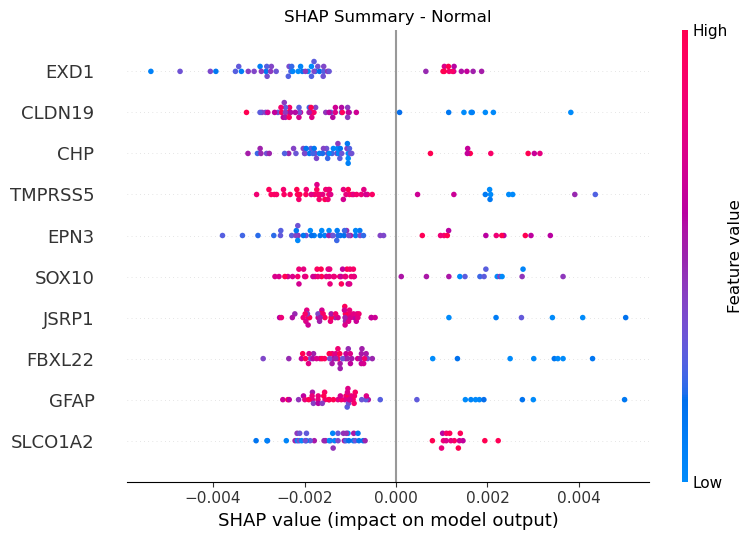

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_40588\1373605258.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


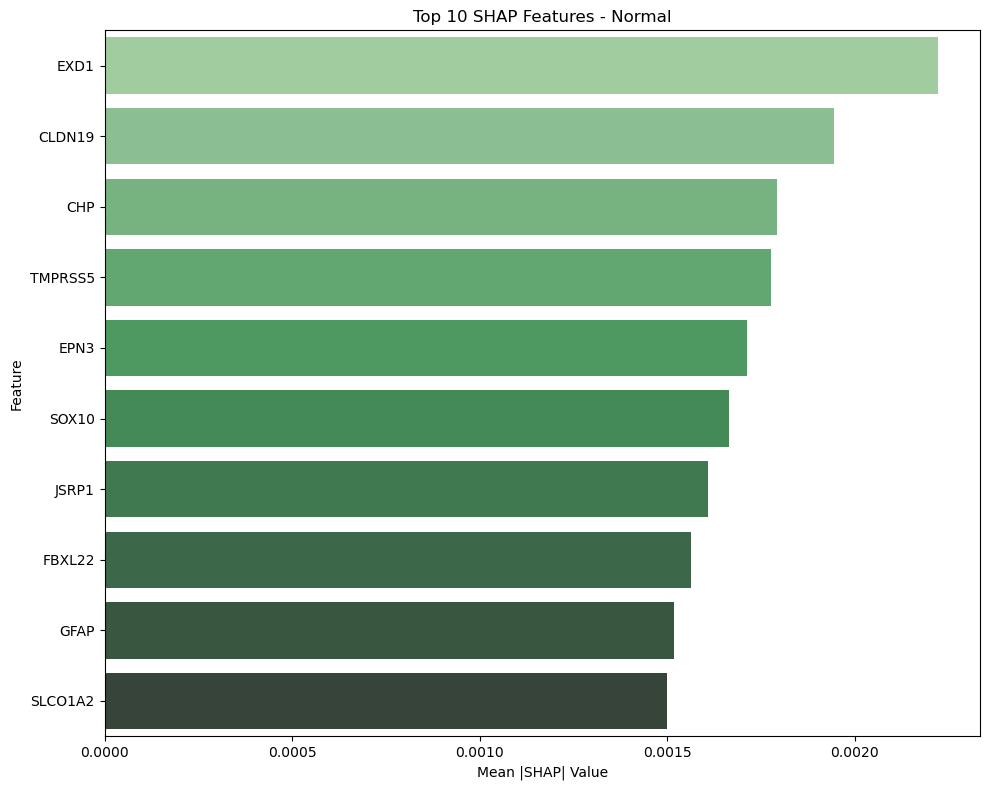


SHAP analysis complete — both overall and per-subtype results generated.


In [7]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_Norway_SMOTE_No_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rf_model = pipeline_model.named_steps['rf']
scaler = pipeline_model.named_steps['scaler']

# --- Prepare data ---
feature_names = np.array(X_test.columns)

# Scale test set
X_test_scaled = scaler.transform(X_test)

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Total features: {len(feature_names)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall,
    X_test_scaled,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_

for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": feature_names,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class,
        X_test_scaled,
        feature_names=feature_names,
        max_display=10,
        show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")